# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





**A quote-aware line splitter**

In [31]:
import numpy as np

def split_csv_line(line):
    """Split one CSV line on commas, ignoring commas inside quotes The reason we wrote this,
     splitter if for country with names like Congo, Dem. Rep. with numpy they tend to break,
     When you simply use line.split(",")"""
    fields, current, inside_quotes = [], "", False
    for ch in line:
        if ch == '"':
            inside_quotes = not inside_quotes   # entering or leaving a quoted field
        elif ch == "," and not inside_quotes:
            fields.append(current)               # comma outside quotes = field boundary
            current = ""
        else:
            current += ch
    fields.append(current)
    return fields

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Read the file and remove the footer junk**

In [33]:
with open("africa_wdi_2010_2022.csv", encoding="utf-8-sig") as f:
    lines = [line.strip() for line in f]

header = split_csv_line(lines[0])
rows = [split_csv_line(l) for l in lines[1:]]

# Real data rows start with a year; this drops the empty lines and the
# "Data from database..." / "Last Updated..." footer rows that was generated during downloading this data set on the world bank
rows = [r for r in rows if r[0].isdigit()]

raw = np.array(rows, dtype=str)
print("Raw shape:", raw.shape)
print("Columns:", header[:4], "+", len(header) - 4, "indicators")

Raw shape: (702, 14)
Columns: ['Time', 'Time Code', 'Country Name', 'Country Code'] + 10 indicators


**Separate the non-numeric columns, and convert `..` to NaN**

In [34]:
# Non-numeric / identifier columns: Time, Time Code, Country Name, Country Code
id_cols = raw[:, :4]

# Shorter feature names for plots (drop the "[NY.GDP.PCAP.CD]" code part)
feature_names = [h.split(" [")[0] for h in header[4:]]

# World Bank marks missing values as ".." -> convert to NaN, then to float
num_raw = raw[:, 4:]
X = np.where(num_raw == "..", "nan", num_raw).astype(float)

print("Numeric feature matrix:", X.shape)
print("Total missing values:", np.isnan(X).sum(), "\n")
for name, m in zip(feature_names, np.isnan(X).sum(axis=0)):
    print(f"{name:<60} {m:>3}  ({m / len(X) * 100:.1f}%)")

Numeric feature matrix: (702, 10)
Total missing values: 141 

GDP per capita (current US$)                                  18  (2.6%)
GDP growth (annual %)                                         22  (3.1%)
Inflation, consumer prices (annual %)                         35  (5.0%)
Agriculture, forestry, and fishing, value added (% of GDP)    36  (5.1%)
Foreign direct investment, net inflows (% of GDP)             29  (4.1%)
Population growth (annual %)                                   1  (0.1%)
Fertility rate, total (births per woman)                       0  (0.0%)
Urban population (% of total population)                       0  (0.0%)
Life expectancy at birth, total (years)                        0  (0.0%)
Access to electricity (% of population)                        0  (0.0%)


**Region column, encoding, and imputation**

In [35]:
country_names = id_cols[:, 2]

region_of = {
    "Northern Africa": ["Algeria", "Egypt, Arab Rep.", "Libya", "Morocco", "Sudan", "Tunisia"],
    "Eastern Africa":  ["Burundi", "Comoros", "Djibouti", "Eritrea", "Ethiopia", "Kenya",
                        "Madagascar", "Malawi", "Mauritius", "Mozambique", "Rwanda", "Seychelles",
                        "Somalia, Fed. Rep.", "South Sudan", "Tanzania", "Uganda", "Zambia", "Zimbabwe"],
    "Central Africa":  ["Angola", "Cameroon", "Central African Republic", "Chad", "Congo, Dem. Rep.",
                        "Congo, Rep.", "Equatorial Guinea", "Gabon", "Sao Tome and Principe"],
    "Southern Africa": ["Botswana", "Eswatini", "Lesotho", "Namibia", "South Africa"],
    "Western Africa":  ["Benin", "Burkina Faso", "Cabo Verde", "Cote d'Ivoire", "Gambia, The", "Ghana",
                        "Guinea", "Guinea-Bissau", "Liberia", "Mali", "Mauritania", "Niger", "Nigeria",
                        "Senegal", "Sierra Leone", "Togo"],
}
country_to_region = {c: r for r, cs in region_of.items() for c in cs}

# Safety check: every country in the file must have a region
unmapped = sorted(set(country_names) - set(country_to_region))
print("Countries without a region:", unmapped)

regions = np.array([country_to_region[c] for c in country_names])
region_names = list(region_of.keys())
for r in region_names:
    print(f"{r:<16} {len(region_of[r]):>2} countries, {np.sum(regions == r):>3} rows")

Countries without a region: []
Northern Africa   6 countries,  78 rows
Eastern Africa   18 countries, 234 rows
Central Africa    9 countries, 117 rows
Southern Africa   5 countries,  65 rows
Western Africa   16 countries, 208 rows


**Encode the non-numeric Region column**

In [36]:
# Label encoding: each region becomes an integer 0-4 (used later for plot colours)
region_code = np.array([region_names.index(r) for r in regions])

# One-hot encoding: one 0/1 column per region, with no fake ordering between regions
region_onehot = (region_code[:, None] == np.arange(len(region_names))).astype(int)

print(region_names)
print("Label codes (first 5):", region_code[:5])
print("One-hot shape:", region_onehot.shape)
print(country_names[:3], "\n", region_onehot[:3])
print("Each row has exactly one 1:", np.all(region_onehot.sum(axis=1) == 1))

['Northern Africa', 'Eastern Africa', 'Central Africa', 'Southern Africa', 'Western Africa']
Label codes (first 5): [2 0 4 4 4]
One-hot shape: (702, 5)
['Angola' 'Algeria' 'Benin'] 
 [[0 0 1 0 0]
 [1 0 0 0 0]
 [0 0 0 0 1]]
Each row has exactly one 1: True


**Three-level median imputation**

In [37]:
def impute_three_level(X, country_names, regions):
    """Fill NaNs with: 1) the country's own median, 2) the sub-region median,
    3) the continent median, in that order of preference."""
    X_filled = X.copy()
    level_counts = {"country median": 0, "region median": 0, "continent median": 0}

    for j in range(X.shape[1]):
        col = X[:, j]
        continent_median = np.nanmedian(col)
        for i in np.where(np.isnan(col))[0]:
            same_country = col[country_names == country_names[i]]
            same_region = col[regions == regions[i]]
            if not np.all(np.isnan(same_country)):
                X_filled[i, j] = np.nanmedian(same_country)
                level_counts["country median"] += 1
            elif not np.all(np.isnan(same_region)):
                X_filled[i, j] = np.nanmedian(same_region)
                level_counts["region median"] += 1
            else:
                X_filled[i, j] = continent_median
                level_counts["continent median"] += 1
    return X_filled, level_counts

was_missing = np.isnan(X)
# keep a record of which values were originally missing
X_imputed, level_counts = impute_three_level(X, country_names, regions)

print("Missing before:", was_missing.sum(), "| after:", np.isnan(X_imputed).sum())
for level, count in level_counts.items():
    print(f"  filled with {level:<17}: {count}")


Missing before: 141 | after: 0
  filled with country median   : 89
  filled with region median    : 52
  filled with continent median : 0


In [38]:
infl = X[:, feature_names.index("Inflation, consumer prices (annual %)")]
print(f"Inflation: mean = {np.nanmean(infl):.1f}% | median = {np.nanmedian(infl):.1f}% | max = {np.nanmax(infl):.1f}%")

Inflation: mean = 10.1% | median = 4.8% | max = 557.2%


### Data Handling: Our Choices

1. **Imputed instead of dropping countries.** Dropping Eritrea and Somalia would leave 52 of 54 countries, so the study would no longer cover the whole continent. In real work some data is always missing, so we fill it.
2. **Median instead of mean.** Inflation has extreme values (Zimbabwe's peak), which pull the mean far above the median (see the output above). The median is the middle value, so one extreme case can't distort the values we fill in.
3. **Region is encoded but kept out of PCA.** If we fed the region labels to PCA, any regional separation in the plot would be something we put in ourselves, not something PCA discovered.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

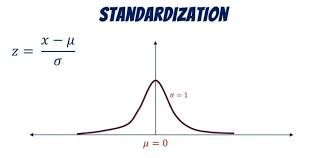


In [39]:
# Step 1: Standardize using z = (x - mu) / sigma  (numpy only)
n = X_imputed.shape[0]

mu = np.sum(X_imputed, axis=0) / n                              # column means
sigma = np.sqrt(np.sum((X_imputed - mu) ** 2, axis=0) / n)      # column standard deviations

standardized_data = (X_imputed - mu) / sigma

np.set_printoptions(precision=3, suppress=True)   # readable output, no scientific notation
standardized_data[:5]  # Display the first few rows of standardized data

array([[ 0.456,  0.267,  0.14 , -0.706, -0.926,  1.515,  1.435,  0.859,
        -0.735, -0.533],
       [ 0.711,  0.191, -0.18 , -0.933, -0.36 , -0.3  , -1.137,  1.246,
         1.726,  1.733],
       [-0.524, -0.221, -0.232,  0.69 , -0.448,  0.689,  0.86 , -0.093,
        -0.568, -0.561],
       [-0.634,  0.75 , -0.322,  0.539, -0.47 ,  0.633,  1.235, -1.129,
        -0.866, -1.309],
       [ 0.293, -0.264, -0.236, -1.084,  0.255, -1.473, -1.56 ,  0.951,
         1.488,  1.102]])

In [40]:
print("Column means (should be ~0):", np.round(np.sum(standardized_data, axis=0) / n, 6))
print("Column std devs (should be 1):", np.round(np.sqrt(np.sum(standardized_data ** 2, axis=0) / n), 6))

Column means (should be ~0): [ 0.  0.  0. -0.  0. -0. -0.  0. -0.  0.]
Column std devs (should be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [41]:
# Step 3: Calculate the Covariance Matrix  (numpy only, from the definition)
# Data is already centered (mean 0), so covariance = (Z^T Z) / (n - 1)
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)

print("Covariance matrix shape:", cov_matrix.shape)
cov_matrix

Covariance matrix shape: (10, 10)


array([[ 1.001, -0.033, -0.063, -0.643,  0.019, -0.293, -0.557,  0.475,
         0.438,  0.619],
       [-0.033,  1.001, -0.125,  0.102,  0.07 ,  0.045,  0.087, -0.103,
        -0.026, -0.06 ],
       [-0.063, -0.125,  1.001,  0.018, -0.049, -0.136, -0.003, -0.1  ,
        -0.103, -0.063],
       [-0.643,  0.102,  0.018,  1.001,  0.06 ,  0.365,  0.63 , -0.56 ,
        -0.356, -0.584],
       [ 0.019,  0.07 , -0.049,  0.06 ,  1.001,  0.095,  0.048,  0.049,
         0.026, -0.085],
       [-0.293,  0.045, -0.136,  0.365,  0.095,  1.001,  0.657, -0.188,
        -0.174, -0.423],
       [-0.557,  0.087, -0.003,  0.63 ,  0.048,  0.657,  1.001, -0.422,
        -0.65 , -0.724],
       [ 0.475, -0.103, -0.1  , -0.56 ,  0.049, -0.188, -0.422,  1.001,
         0.406,  0.626],
       [ 0.438, -0.026, -0.103, -0.356,  0.026, -0.174, -0.65 ,  0.406,
         1.001,  0.672],
       [ 0.619, -0.06 , -0.063, -0.584, -0.085, -0.423, -0.724,  0.626,
         0.672,  1.001]])

In [42]:
# Find the strongest negative and positive relationships (ignoring the diagonal)
off_diag = cov_matrix - np.diag(np.diag(cov_matrix))
i, j = np.unravel_index(np.argmin(off_diag), off_diag.shape)
print(f"Most negative: {feature_names[i]}  vs  {feature_names[j]}  = {off_diag[i, j]:.3f}")
i, j = np.unravel_index(np.argmax(off_diag), off_diag.shape)
print(f"Most positive: {feature_names[i]}  vs  {feature_names[j]}  = {off_diag[i, j]:.3f}")

Most negative: Fertility rate, total (births per woman)  vs  Access to electricity (% of population)  = -0.724
Most positive: Life expectancy at birth, total (years)  vs  Access to electricity (% of population)  = 0.672


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Why we compute the covariance matrix

First,the covariance matrix shows how our features move together. For example, our two strongest pairs show that African countries with more access to electricity tend to have fewer children per family (−0.724) and tend to have people living longer (+0.672). Second, the covariance matrix is also the matrix we decompose in the next step to find the principal components, so PCA cannot be done without it.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [43]:
# Step 4: Perform Eigendecomposition
# eigh is designed for symmetric matrices (a covariance matrix is always symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.127, 0.202, 0.346, 0.524, 0.732, 0.76 , 0.963, 1.   , 1.283,
        4.076]),
 array([[ 0.024,  0.23 ,  0.551,  0.606, -0.052,  0.335,  0.029,  0.055,
         -0.109, -0.379],
        [ 0.026,  0.018, -0.058, -0.095,  0.228,  0.348,  0.128, -0.803,
         -0.387,  0.056],
        [ 0.019,  0.006, -0.003, -0.012,  0.554,  0.289,  0.465,  0.06 ,
          0.623,  0.027],
        [ 0.28 ,  0.151,  0.685, -0.191,  0.218, -0.427,  0.023, -0.093,
         -0.031,  0.39 ],
        [-0.017, -0.111, -0.027,  0.008, -0.183, -0.14 ,  0.84 ,  0.224,
         -0.42 ,  0.025],
        [ 0.397, -0.15 , -0.21 ,  0.239,  0.478,  0.191, -0.208,  0.402,
         -0.415,  0.277],
        [-0.764, -0.117,  0.25 , -0.07 ,  0.064,  0.286, -0.091,  0.186,
         -0.135,  0.434],
        [ 0.095,  0.352,  0.113, -0.697,  0.046,  0.334, -0.046,  0.307,
         -0.197, -0.344],
        [-0.411,  0.318, -0.16 ,  0.107,  0.535, -0.494, -0.027, -0.002,
         -0.2  , -0.349],
        [-0.021, -0.8

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [44]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]         # indices from largest to smallest eigenvalue
sorted_eigenvalues = eigenvalues[sorted_indices]      # eigenvalues in descending order
sorted_eigenvectors = eigenvectors[:, sorted_indices] # reorder COLUMNS, not rows

print("Sorted eigenvalues (descending):", sorted_eigenvalues)
sorted_eigenvectors

Sorted eigenvalues (descending): [4.076 1.283 1.    0.963 0.76  0.732 0.524 0.346 0.202 0.127]


array([[-0.379, -0.109,  0.055,  0.029,  0.335, -0.052,  0.606,  0.551,
         0.23 ,  0.024],
       [ 0.056, -0.387, -0.803,  0.128,  0.348,  0.228, -0.095, -0.058,
         0.018,  0.026],
       [ 0.027,  0.623,  0.06 ,  0.465,  0.289,  0.554, -0.012, -0.003,
         0.006,  0.019],
       [ 0.39 , -0.031, -0.093,  0.023, -0.427,  0.218, -0.191,  0.685,
         0.151,  0.28 ],
       [ 0.025, -0.42 ,  0.224,  0.84 , -0.14 , -0.183,  0.008, -0.027,
        -0.111, -0.017],
       [ 0.277, -0.415,  0.402, -0.208,  0.191,  0.478,  0.239, -0.21 ,
        -0.15 ,  0.397],
       [ 0.434, -0.135,  0.186, -0.091,  0.286,  0.064, -0.07 ,  0.25 ,
        -0.117, -0.764],
       [-0.344, -0.197,  0.307, -0.046,  0.334,  0.046, -0.697,  0.113,
         0.352,  0.095],
       [-0.349, -0.2  , -0.002, -0.027, -0.494,  0.535,  0.107, -0.16 ,
         0.318, -0.411],
       [-0.44 , -0.051, -0.018, -0.075, -0.081,  0.193, -0.163,  0.278,
        -0.806, -0.021]])

In [45]:
# Explained variance: share of total variance captured by each component
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':<6}{'Eigenvalue':>11}{'Explained %':>14}{'Cumulative %':>15}")
for k in range(len(sorted_eigenvalues)):
    print(f"PC{k+1:<4}{sorted_eigenvalues[k]:>11.3f}"
          f"{explained_variance_ratio[k]*100:>13.2f}%{cumulative_variance[k]*100:>14.2f}%")

PC     Eigenvalue   Explained %   Cumulative %
PC1         4.076        40.70%         40.70%
PC2         1.283        12.81%         53.51%
PC3         1.000         9.99%         63.50%
PC4         0.963         9.61%         73.12%
PC5         0.760         7.59%         80.71%
PC6         0.732         7.31%         88.02%
PC7         0.524         5.23%         93.26%
PC8         0.346         3.46%         96.71%
PC9         0.202         2.02%         98.73%
PC10        0.127         1.27%        100.00%


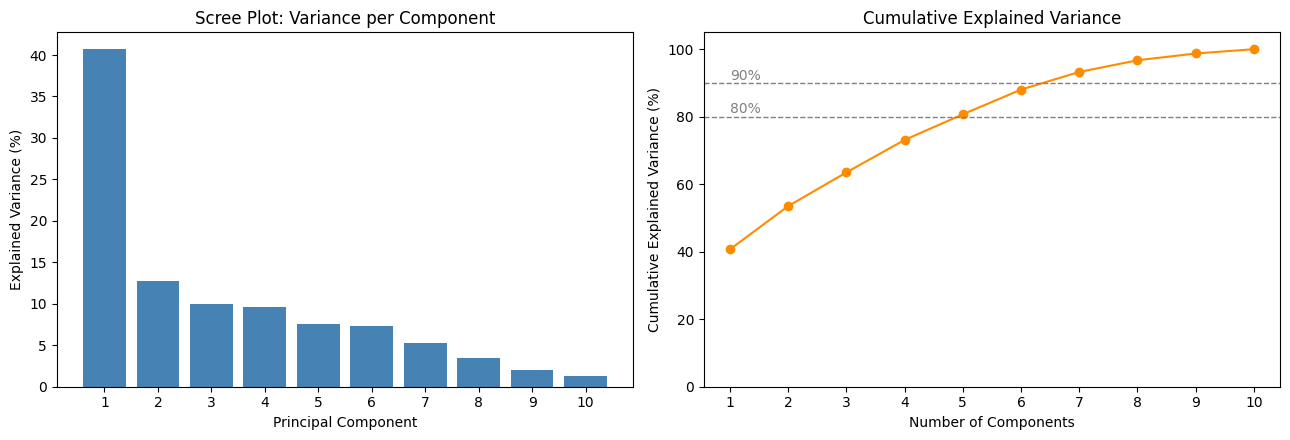

In [46]:
import matplotlib.pyplot as plt

pcs = np.arange(1, len(sorted_eigenvalues) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.bar(pcs, explained_variance_ratio * 100, color="steelblue")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_title("Scree Plot: Variance per Component")
ax1.set_xticks(pcs)

ax2.plot(pcs, cumulative_variance * 100, marker="o", color="darkorange")
for t in [80, 90]:
    ax2.axhline(t, linestyle="--", color="gray", linewidth=1)
    ax2.text(1, t + 1, f"{t}%", color="gray")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance (%)")
ax2.set_title("Cumulative Explained Variance")
ax2.set_xticks(pcs)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [47]:
def select_num_components(sorted_eigenvalues, threshold):
    """Return the smallest number of components whose cumulative
    explained variance reaches the threshold (e.g. 0.80 = 80%)."""
    cumulative = np.cumsum(sorted_eigenvalues) / np.sum(sorted_eigenvalues)
    return int(np.argmax(cumulative >= threshold) + 1)   # first position that reaches it

for t in [0.70, 0.80, 0.90, 0.95]:
    print(f"Threshold {t:.0%}: keep {select_num_components(sorted_eigenvalues, t)} components")

Threshold 70%: keep 4 components
Threshold 80%: keep 5 components
Threshold 90%: keep 7 components
Threshold 95%: keep 8 components


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [48]:
# Step 6: Project Data onto Principal Components
chosen_threshold = 0.90

num_components = select_num_components(sorted_eigenvalues, chosen_threshold)   # chosen dynamically
projection_matrix = sorted_eigenvectors[:, :num_components]   # first k eigenvector COLUMNS
reduced_data = standardized_data @ projection_matrix          # (702 x 10) @ (10 x k) = (702 x k)

print(f"Threshold {chosen_threshold:.0%} -> keeping {num_components} components, "
      f"explaining {cumulative_variance[num_components - 1] * 100:.2f}% of the variance")
reduced_data[:5]

Threshold 90% -> keeping 7 components, explaining 93.26% of the variance


array([[ 0.785, -0.474,  0.828, -1.105,  2.111,  0.49 ,  0.048],
       [-3.008, -0.484, -0.102, -0.431, -0.258,  0.868, -0.368],
       [ 1.48 , -0.076,  0.389, -0.672,  0.121,  0.048, -0.23 ],
       [ 2.451, -0.209, -0.65 , -0.525,  0.421, -0.158,  0.414],
       [-2.966,  0.131, -0.241,  0.335, -0.868, -0.24 , -0.512]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [49]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (702, 7)


array([[ 0.785, -0.474,  0.828, -1.105,  2.111,  0.49 ,  0.048],
       [-3.008, -0.484, -0.102, -0.431, -0.258,  0.868, -0.368],
       [ 1.48 , -0.076,  0.389, -0.672,  0.121,  0.048, -0.23 ],
       [ 2.451, -0.209, -0.65 , -0.525,  0.421, -0.158,  0.414],
       [-2.966,  0.131, -0.241,  0.335, -0.868, -0.24 , -0.512]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

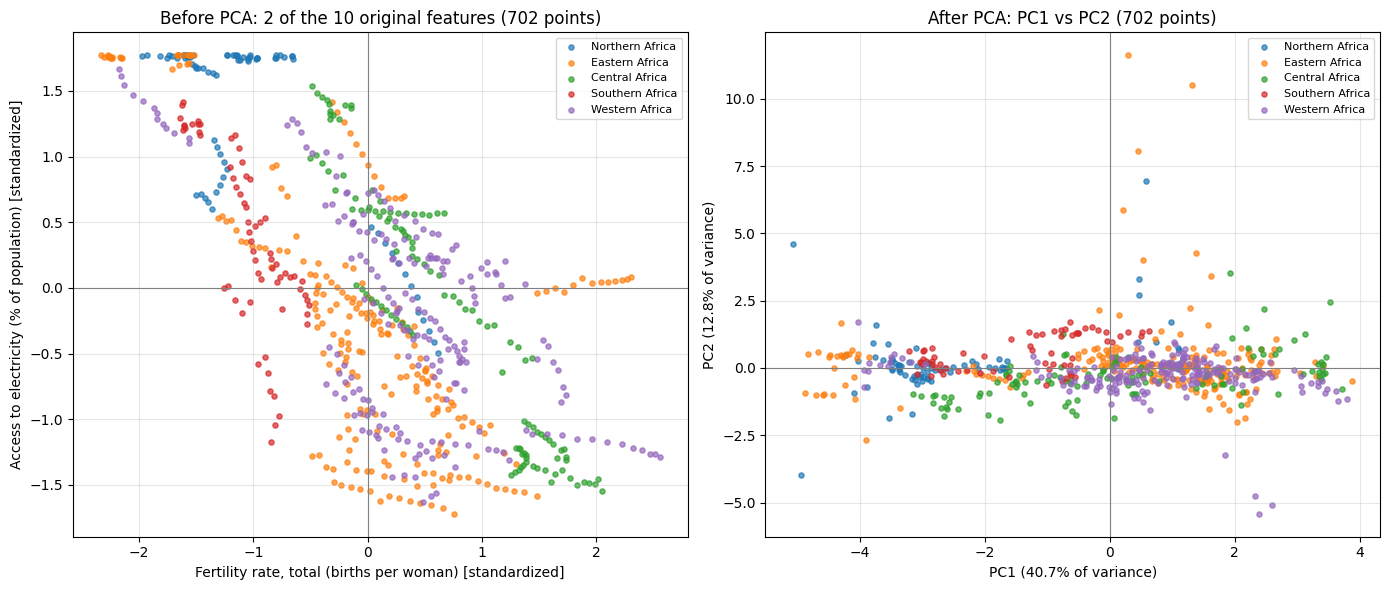

Variance of PC1: 4.070 | PC2: 1.281
Mean of PC1: 0.000 | PC2: 0.000


In [50]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

fx = feature_names.index("Fertility rate, total (births per woman)")
fy = feature_names.index("Access to electricity (% of population)")
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for r, name in enumerate(region_names):
    m = region_code == r
    # Plot original data (two of the original features)
    ax1.scatter(standardized_data[m, fx], standardized_data[m, fy],
                s=14, alpha=0.7, color=colors[r], label=name)
    # Plot reduced data after PCA
    ax2.scatter(reduced_data[m, 0], reduced_data[m, 1],
                s=14, alpha=0.7, color=colors[r], label=name)

ax1.set_xlabel("Fertility rate, total (births per woman) [standardized]")
ax1.set_ylabel("Access to electricity (% of population) [standardized]")
ax1.set_title(f"Before PCA: 2 of the 10 original features ({standardized_data.shape[0]} points)")

ax2.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% of variance)")
ax2.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% of variance)")
ax2.set_title(f"After PCA: PC1 vs PC2 ({reduced_data.shape[0]} points)")

for ax in (ax1, ax2):
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variance of PC1: {np.var(reduced_data[:, 0]):.3f} | PC2: {np.var(reduced_data[:, 1]):.3f}")
print(f"Mean of PC1: {np.mean(reduced_data[:, 0]):.3f} | PC2: {np.mean(reduced_data[:, 1]):.3f}")


### Task 3: Optimization and Benchmarking

In [51]:
import time

def pca_loops(X, k):
    """Naive PCA with Python loops, used only as a slow baseline."""
    n, d = X.shape
    Z = np.zeros_like(X)
    for j in range(d):
        mu = sum(X[:, j]) / n
        sd = (sum((x - mu) ** 2 for x in X[:, j]) / n) ** 0.5
        Z[:, j] = (X[:, j] - mu) / sd
    C = np.zeros((d, d))
    for a in range(d):
        for b in range(d):
            C[a, b] = sum(Z[i, a] * Z[i, b] for i in range(n)) / (n - 1)
    vals, vecs = np.linalg.eig(C)          # general solver
    order = np.argsort(vals.real)[::-1]
    return Z @ vecs[:, order[:k]].real

def pca_fast(X, k):
    """Optimized PCA: vectorized numpy + eigh (for symmetric matrices)."""
    n = X.shape[0]
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    C = (Z.T @ Z) / (n - 1)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    return Z @ vecs[:, order[:k]], vals[order]

a chunked version for datasets too large for memory

In [52]:
def pca_chunked(X, k, chunk_size=100_000):
    """PCA that reads data in chunks: only sums are kept in memory,
    so it scales to datasets too large to standardize all at once."""
    n, d = X.shape
    total, total_sq, cross = np.zeros(d), np.zeros(d), np.zeros((d, d))
    for s in range(0, n, chunk_size):
        B = X[s:s + chunk_size]
        total += B.sum(axis=0)
        total_sq += (B ** 2).sum(axis=0)
        cross += B.T @ B
    mu = total / n
    sd = np.sqrt(total_sq / n - mu ** 2)
    C = (cross / n - np.outer(mu, mu)) / np.outer(sd, sd) * n / (n - 1)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    W = vecs[:, order[:k]]
    projected = [((X[s:s + chunk_size] - mu) / sd) @ W for s in range(0, n, chunk_size)]
    return np.vstack(projected), vals[order]

benchmark

In [53]:
k = num_components

# 1) Loops vs vectorized on our real data
t = time.perf_counter(); slow = pca_loops(X_imputed, k); t_slow = time.perf_counter() - t
t = time.perf_counter(); fast, _ = pca_fast(X_imputed, k); t_fast = time.perf_counter() - t
print(f"Our data (702 rows): loops {t_slow:.4f}s | vectorized {t_fast:.4f}s | "
      f"{t_slow / t_fast:.0f}x faster")
print("Same result (up to sign):", np.allclose(np.abs(slow), np.abs(fast)))

# 2) Scaling to large datasets (resampled from our data with small noise)
rng = np.random.default_rng(42)
print(f"\n{'Rows':>10} {'Vectorized (s)':>15} {'Chunked (s)':>12} {'Same eigenvalues':>17}")
for rows in [10_000, 100_000, 1_000_000]:
    idx = rng.integers(0, len(X_imputed), rows)
    big = X_imputed[idx] * (1 + 0.01 * rng.standard_normal((rows, X_imputed.shape[1])))
    t = time.perf_counter(); _, v1 = pca_fast(big, k); a = time.perf_counter() - t
    t = time.perf_counter(); _, v2 = pca_chunked(big, k); b = time.perf_counter() - t
    print(f"{rows:>10,} {a:>15.3f} {b:>12.3f} {str(np.allclose(v1, v2)):>17}")

Our data (702 rows): loops 0.1530s | vectorized 0.0031s | 49x faster
Same result (up to sign): True

      Rows  Vectorized (s)  Chunked (s)  Same eigenvalues
    10,000           0.006        0.008              True
   100,000           0.103        0.065              True
 1,000,000           1.187        1.143              True


:Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. The before plot shows only 2 of the 10 standardized features(fertility vs electricity access), and hides the other 8. After PCA, each point sits on PC1 (40.7%) and PC2 (12.8%), which combine all 10 indicators. PC1 is a development axis: high fertility, agriculture and population growth versus high electricity, GDP per capita, life expectancy and urbanisation. PC2 is mostly inflation vs growth/FDI and spreads the points much less. The two axes show only 53.5% of the variance, so this is a summary view.
2. We used a 90% cumulative variance threshold, which gives 7 components and 93.26% of the variance. A lower cut-off (e.g. 3 components, 63.5%) would compress more but lose too much information. A higher one (8 components, 95%) would keep noise for little gain. The tradeoff is 30% fewer dimensions and less noise, in exchange for losing 6.7% of the variance. We plot only PC1 vs PC2 for visualisation, not as the final reduction.
3. Economic activity vs the population pressure. These two are blended into PC1, so 'walthy with high fertility' and 'poor with low fertility' can look the same.
   Fine details are lost because the dropped components hold small contrasts such as GDP per capita vs agriculture share and fertility vs population growth.
   Some original units like % with electricity are no longer readable.